In [24]:
#imports
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import pandas as pd
import numpy as np
import time

from dask.distributed import Client, LocalCluster
from formulaic import Formula

import scMPRAforge as scm


In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
cluster=LocalCluster()
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

In [27]:
shendure=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/shendure/shendure_counts_grouped.txt")

scMPRAforge: INFO: Dropping cell-types & cres with below 3 (MIN_PTS) observations: f{'cre_id': ['Col1a1_chr11_15306', 'Col1a2_chr6_65', 'minP_w_20bp_buffer'], 'cell_type': []}
scMPRAforge: INFO: Dropping 4990 cells with no MPRA UMIs, leaving 38457.


In [28]:
shendure_subset=shendure.data[shendure.data["cell_type"]=="EpiblastPrimitiveStreak"]
shendure_mean=shendure_subset.groupby("cre_id")["umis_mpra_bc"].agg("mean").sort_values()
shendure_mean

cre_id
Cited2_chr10_1239      0.000000
Txndc12_chr4_7969      0.000000
Tgfbi_chr13_5711       0.000000
Klf4_chr4_3952         0.000000
Sox17_chr1_68          0.000000
                        ...    
Tubb2b_chr13_2576      8.500901
Btg1_chr10_9578       11.981481
ubcP                  52.924898
pgk1P                153.751531
eef1aP               439.323718
Name: umis_mpra_bc, Length: 209, dtype: float64

In [29]:
def create_matricies(nb_formula,zi_formula,shared_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    S=Formula(shared_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z,
        'shared_regressors':S
    }

matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cre_id)",
                           zi_formula="C(rep_id)",
                           shared_formula='ln_cell_umis_mpra',
                           scmpra=shendure_subset)

In [30]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """

    from tensorzinb.tensorzinb import TensorZINB

    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"],
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except InvalidIndexError:
        return "index_error"

    return zinb_result

model=tensorzinb_fit(matricies)

In [31]:
model

{'llf_total': -57391.16334007494,
 'llfs': array([-57391.16334007]),
 'aic_total': 115214.32668014988,
 'aics': array([115214.32668015]),
 'df_model_total': 216,
 'df': 216,
 'weights': {'x_mu': array([[-3.52143884e+00],
         [ 3.19986135e-01],
         [-5.14739215e-01],
         [ 2.53791898e-01],
         [ 3.76358151e+00],
         [ 2.07083166e-01],
         [-1.54700232e+00],
         [ 3.35141689e-01],
         [ 3.96357864e-01],
         [-8.18586528e-01],
         [ 6.00885534e+00],
         [-4.66811031e-01],
         [ 7.23100007e-01],
         [ 2.72715002e-01],
         [-2.72632778e-01],
         [ 3.24731517e+00],
         [ 4.62224436e+00],
         [ 5.45750618e+00],
         [ 8.60987961e-01],
         [ 2.60785055e+00],
         [ 4.73411828e-01],
         [-2.81488299e-01],
         [-2.30292797e+01],
         [ 3.36432934e-01],
         [-1.12523186e+00],
         [ 1.43681204e+00],
         [ 4.61394405e+00],
         [-3.65259498e-01],
         [ 1.78406566e-

In [32]:
matricies["nb_regressors"]

,Intercept,C(cre_id)[T.Bend5_chr4_8170],C(cre_id)[T.Bend5_chr4_8172],C(cre_id)[T.Bend5_chr4_8174],C(cre_id)[T.Bend5_chr4_8175],C(cre_id)[T.Bend5_chr4_8179],C(cre_id)[T.Bend5_chr4_8192],C(cre_id)[T.Bend5_chr4_8199],C(cre_id)[T.Bend5_chr4_8201],C(cre_id)[T.Btg1_chr10_9572],...,C(cre_id)[T.Txndc12_chr4_7969],C(cre_id)[T.Txndc12_chr4_7971],C(cre_id)[T.Txndc12_chr4_7973],C(cre_id)[T.Txndc12_chr4_7975],C(cre_id)[T.Txndc12_chr4_7978],C(cre_id)[T.eef1aP],C(cre_id)[T.minP],C(cre_id)[T.noP],C(cre_id)[T.pgk1P],C(cre_id)[T.ubcP]
9,1.0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,1.0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
11,1.0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
12,1.0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
13,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736477,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
736478,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
736479,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
736480,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [33]:
len(model["weights"]["x_mu"])

209

In [34]:
#x_mu * beta_g,mu
linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]

#x_mu * beta_g,mu + Z_mu * alpha_mu
#linear_mu=(matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]+
#        matricies["shared_regressors"].to_numpy() @ model["weights"]["z_mu"])
mu_predictions=np.exp(linear_mu)

#x_pi * beta_g,pi + Z_pi * alpha_pi
#linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"]+
#           matricies["shared_regressors"].to_numpy() @ model["weights"]["z_pi"])


#x_pi * beta_g,pi
linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

In [35]:
cre_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cre_id"]
cre_labeling=cre_labeling.str.removeprefix("T.")

In [36]:
mu_predictions_df=pd.DataFrame({'cre_id':cre_labeling,'mu':mu_predictions.squeeze()})
mu_predictions_df.sort_values(by='mu')

,cre_id,mu
166914,Col5a1_chr2_2586,2.132880e-14
438389,Col5a1_chr2_2586,2.132880e-14
687084,Col5a1_chr2_2586,2.132880e-14
662996,Col5a1_chr2_2586,2.132880e-14
603817,Col5a1_chr2_2586,2.132880e-14
...,...,...
447919,eef1aP,4.463675e+02
414482,eef1aP,4.463675e+02
458144,eef1aP,4.463675e+02
424154,eef1aP,4.463675e+02


In [37]:
mu_summary=mu_predictions_df.groupby("cre_id").agg("mean")
mu_summary = mu_summary.merge(shendure_mean.rename_axis('cre_id').reset_index(), on='cre_id', how='left')
mu_summary.sort_values(by="mu")

,cre_id,mu,umis_mpra_bc
50,Col5a1_chr2_2586,2.132880e-14,0.000000
21,Cited2_chr10_1239,2.945571e-12,0.000000
152,Sox17_chr1_78,3.797340e-11,0.000000
148,Sox17_chr1_68,1.661472e-10,0.000000
102,Klf4_chr4_3952,2.715714e-09,0.000000
...,...,...,...
189,Tubb2b_chr13_2576,8.600857e+00,8.500901
9,Btg1_chr10_9578,1.203016e+01,11.981481
207,ubcP,5.313989e+01,52.924898
206,pgk1P,1.543544e+02,153.751531


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

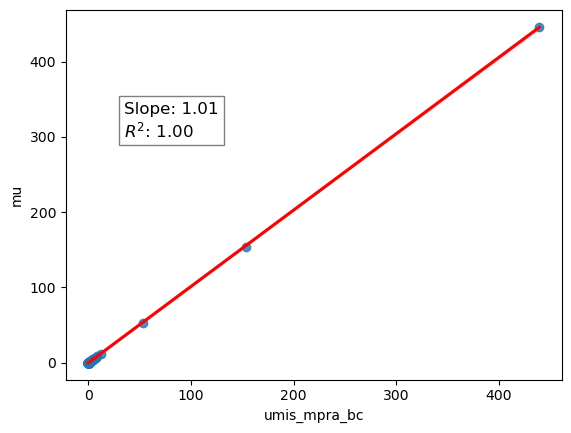

In [47]:
x = mu_summary["umis_mpra_bc"]
y = mu_summary["mu"]

# Fit regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plot
sns.regplot(x=x, y=y, scatter=True, line_kws={"color": "red"})
plt.text(
    35, 300,  # coordinates for text box
    f"Slope: {slope:.2f}\n$R^2$: {r_value**2:.2f}",
    fontsize=12, bbox=dict(facecolor='white', alpha=0.5)
)

plt.show()


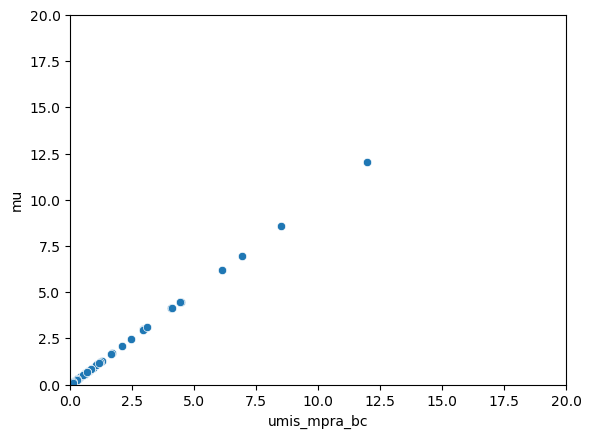

In [46]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 20)   # Set x-axis limits
plt.ylim(0, 20)   # Set y-axis limits
plt.show()

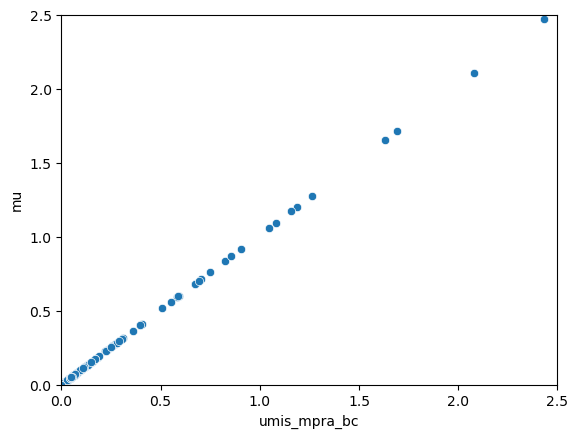

In [45]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 2.5)   # Set x-axis limits
plt.ylim(0, 2.5)   # Set y-axis limits
plt.show()

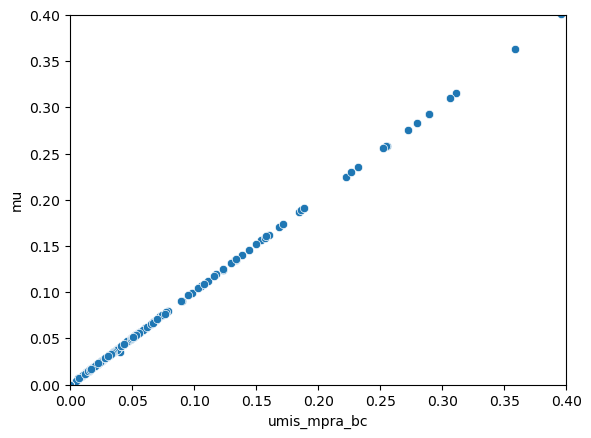

In [44]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 0.4)   # Set x-axis limits
plt.ylim(0, 0.4)   # Set y-axis limits
plt.show()

In [48]:
replicate_labeling=scm.undo_one_hot_encoding(matricies["zi_regressors"])["rep_id"]
replicate_labeling=replicate_labeling.str.removeprefix("T.")
zi_predictions_df=pd.DataFrame({'rep_id':replicate_labeling,'zi':zi_predictions.squeeze()})
zi_summary=zi_predictions_df.groupby("rep_id").agg("mean")
zi_summary




,zi
rep_id,
2B2,0.015200
A1,0.010807
A2,0.016718
B1,0.009533
B2,0.009400


------

In [ ]:
#dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
#primordial=scm.ortho()
#primordial.criss_cross(client=client,dat=dat)
#primordial.extract_params(client)

scMPRAforge: INFO: [timed_fit] nobody took 0.67 seconds
scMPRAforge: INFO: [timed_fit] redgene took 0.88 seconds
scMPRAforge: INFO: [timed_fit] neurogene took 0.88 seconds
scMPRAforge: INFO: [timed_fit] everybody took 0.89 seconds
scMPRAforge: INFO: [timed_fit] somebody took 0.91 seconds
scMPRAforge: INFO: [timed_fit] brain took 0.99 seconds
scMPRAforge: INFO: [timed_fit] blood took 1.07 seconds


In [ ]:
#primordial.by_cell_type_parameters.result().theta

{'brain': array(1.3041191, dtype=float32),
 'blood': array(1.1990892, dtype=float32)}

In [49]:
cluster.close()